In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("somya2115/placement-csv")

print("Path to dataset files:", path)

100%|██████████| 725/725 [00:00<00:00, 421kB/s]

Extracting files...
Path to dataset files: C:\Users\mishr\.cache\kagglehub\datasets\somya2115\placement-csv\versions\1


In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import mlxtend

In [6]:
df=pd.read_csv(r"C:\Users\mishr\.cache\kagglehub\datasets\somya2115\placement-csv\versions\1\placement.csv")
df


,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0
...,...,...,...,...
95,95,4.3,200.0,0
96,96,4.4,42.0,0
97,97,6.7,182.0,1
98,98,6.3,103.0,1


In [7]:
df.head()

,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0


In [8]:
df.shape

(100, 4)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  100 non-null    int64  
 1   cgpa        100 non-null    float64
 2   iq          100 non-null    float64
 3   placement   100 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 3.3 KB


In [10]:
df.describe()

,Unnamed: 0,cgpa,iq,placement
count,100.000000,100.000000,100.000000,100.000000
mean,49.500000,5.991000,123.580000,0.500000
std,29.011492,1.143634,39.944198,0.502519
min,0.000000,3.300000,37.000000,0.000000
25%,24.750000,5.075000,101.500000,0.000000
50%,49.500000,6.000000,127.500000,0.500000
75%,74.250000,6.900000,149.000000,1.000000
max,99.000000,8.500000,233.000000,1.000000


In [11]:
df=df.iloc[:,1:]

In [12]:
df.head()

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0


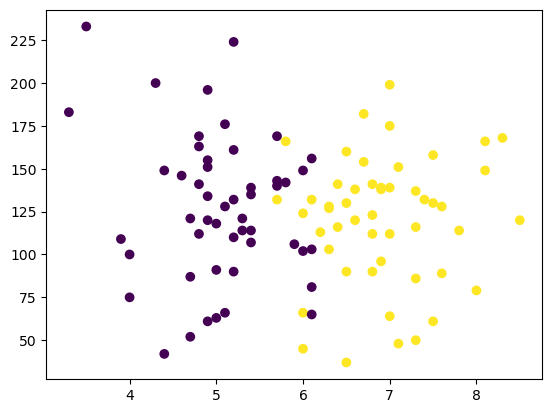

In [13]:
plt.scatter(df['cgpa'],df['iq'],c=df['placement'])

In [17]:
ip=df.drop('placement',axis=1)
df

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0
...,...,...,...
95,4.3,200.0,0
96,4.4,42.0,0
97,6.7,182.0,1
98,6.3,103.0,1


In [16]:
op=df.placement
op

0     1
1     0
2     0
3     1
4     0
     ..
95    0
96    0
97    1
98    1
99    1
Name: placement, Length: 100, dtype: int64

In [18]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
   ip,op,
    train_size=0.8,
    random_state=3000
)

In [19]:

from sklearn.preprocessing import StandardScaler

sc = StandardScaler() 

x_train = sc.fit_transform(x_train) 

x_test = sc.transform(x_test) 

In [20]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()

lr.fit(x_train, y_train)

predlr = lr.predict(x_test)

In [22]:
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score

ac = accuracy_score(y_test, predlr)

rc = recall_score(y_test, predlr, average='macro')

pr = precision_score(y_test, predlr, average='macro')

f1 = f1_score(y_test, predlr, average='macro')

print("Accuracy =", ac)
print("Recall =", rc)
print("Precision =", pr)
print("F1 Score =", f1)

Accuracy = 0.85
Recall = 0.8535353535353536
Precision = 0.8500000000000001
F1 Score = 0.849624060150376


In [28]:
from mlxtend.plotting import plot_decision_regions

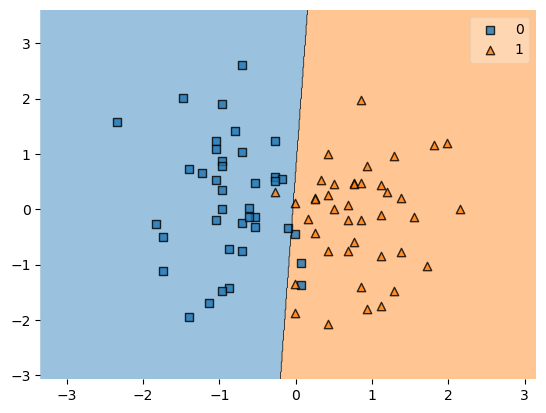

In [34]:
plot_decision_regions(
    X=x_train,
    y=y_train.values,
    clf=lr
)

plt.show()